# 0. Pomoćne funkcije

Ovdje su definirane funkcije za treniranje modela, evaluaciju i vizualizaciju rezultata.

In [21]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import matplotlib.pyplot as plt
import matplotlib

def root_mean_squared_error(y_true, y_pred):
    """Calculate the root mean squared error."""
    return mean_squared_error(y_true, y_pred, squared=False)

# matplotlib.rcParams.update({'font.size': 20})


def train_svm(X_train, y_train):
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1]
    }

    svr = SVR(kernel='rbf')

    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


def train_rf(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt']
    }

    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


def train_histgb(X_train, y_train):
    param_dist = {
        'learning_rate': uniform(0.01, 0.1),
        'max_iter': randint(100, 300),
        'max_depth': randint(3, 10),
        'min_samples_leaf': randint(10, 50),
        'l2_regularization': uniform(0.0, 1.0)
    }

    model = HistGradientBoostingRegressor(
        early_stopping=True,
        random_state=42
    )

    grid_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='neg_mean_squared_error',
        cv=3,
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


def evaluate_model(model, X_train, y_train, X_test, y_test, time=None):
    if time is not None:
        print(f"\n⏱️ Training Time: {time:.2f} seconds")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = root_mean_squared_error(y_train, train_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    test_mse = root_mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"📊 Train RMSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}")
    print(f"📊 Test  RMSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}\n")


def visualize_results(y_true, y_pred, title="Model Predictions vs True Values"):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('Prave vrijednosti pIC50')
    plt.ylabel('Predviđene vrijednosti pIC50')
    plt.title(title)
    plt.grid()
    plt.tight_layout()
    plt.show()

# 1. Pretprocesiranje podataka

Ova bilježnica istražuje kako kombinacija različitih molekularnih reprezentacija utječe na kvalitetu predikcije molekularnih svojstava. Za početak se učitava skup podataka koji se sastoji od 4200 uzoraka, a sastoji se od SMILES zapisa molekula te njihovih vrijednosti molekularnog svojstva _lipo_ (lipofilnost). Provjerava se jesu li molekule valjane te se pretvaraju u kanonski oblik kako bi njihovi SMILES zapisi bili jednoznačni.

In [66]:
import deepchem as dc
tasks, datasets, transformers = dc.molnet.load_lipo(
    featurizer='ecfp',  # use ECFP featurizer
    splitter='scaffold',
    reload=False  # disable loading from cached directory
)

In [23]:
import numpy as np

(train, val, test) = datasets

train_smiles = np.concatenate([train.ids, val.ids], axis=0)
test_smiles = test.ids

train_y = [value[0] for value in train.y] + [value[0] for value in val.y]
test_y = [value[0] for value in test.y]

len(train_smiles), len(test_smiles)

(3780, 420)

Skup je izvorno podijeljen na skup za treniranje, validaciju i testiranje. No, za potrebe primjene unakrsne validacije, skupovi za treniranje i testiranje se objedinjuju. Rezultantni skup sadrži 3780 molekula za treniranje i 420 molekula za testiranje.

In [24]:
from rdkit import Chem

train_smiles = [Chem.CanonSmiles(smiles) for smiles in train_smiles]
test_smiles = [Chem.CanonSmiles(smiles) for smiles in test_smiles]

In [25]:
# provjera jesu li svi SMILES zapisi dohvaćeni

import pandas as pd

data_train = pd.DataFrame({'smiles': train_smiles, 'lipo': train_y, 'train': [True for _ in range(len(train_smiles))]})
data_test = pd.DataFrame({'smiles': test_smiles, 'lipo': test_y, 'train': [False for _ in range(len(test_smiles))]})

data = pd.concat([data_train, data_test], ignore_index=True)

data.isna().sum()

smiles    0
lipo      0
train     0
dtype: int64

Svi zapisi su dohvaćeni, nema nedostajućih podataka. Nadalje, ciljna značajka _lipo_ skalira se na vrijednosti između 0 i 1.

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['lipo'] = scaler.fit_transform(np.array(data['lipo']).reshape(-1,1))
data.head()

,smiles,lipo,train
0,CNC(=O)c1nc(-c2ccc(Cl)c(S(=O)(=O)Nc3cccc(F)c3F...,0.716667,True
1,O=C(COc1ccccc1O)NC1CCCC1,0.635000,True
2,COCCNS(=O)(=O)c1ccc(-c2cnc(N)c(C(=O)Nc3cccnc3)...,0.626667,True
3,COC1/C=C/OC2(C)Oc3c(C)c(O)c4c(c3C2=O)C(=O)C=C(...,0.366667,True
4,C[C@@H](Oc1cccc2ncnc(Nc3ccc4c(cnn4Cc4ccccn4)c3...,0.720000,True


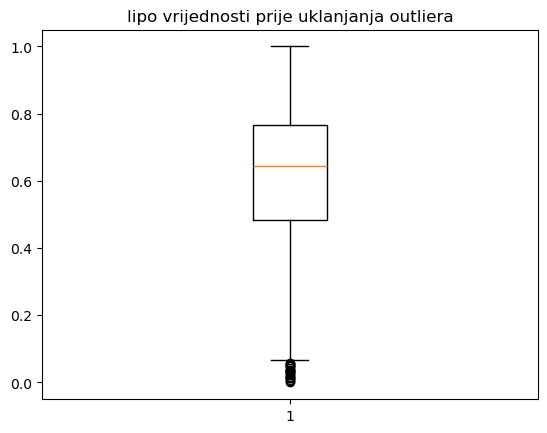

In [27]:
# provjera postoje li stršeće vrijednosti

plt.boxplot(data['lipo'])
plt.title('lipo vrijednosti prije uklanjanja outliera')
plt.show()

Stršeće vrijednosti postoje, te se uklanjaju korištenjem interkvartilnog raspona (IQR).

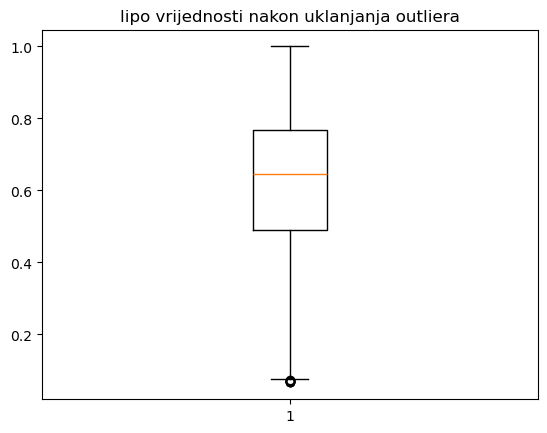

4178


In [28]:
Q1 = data['lipo'].quantile(0.25)
Q3 = data['lipo'].quantile(0.75)
IQR = Q3 - Q1    #IQR is interquartile range. 

filter = (data['lipo'] >= Q1 - 1.5 * IQR) & (data['lipo'] <= Q3 + 1.5 *IQR)
data = data.loc[filter]
data.reset_index(drop=True, inplace=True)


plt.boxplot(data['lipo'] )
plt.title('lipo vrijednosti nakon uklanjanja outliera')
plt.show()

print(len(data))

Uklonjeno je 22 zapisa, što čini samo 0.52% skupa.

# 2. Molekularne reprezentacije
U nastavku ćemo generirati nekoliko različitih molekularnih reprezentacija: molekularne deskriptore, molekularne otiske te molekularne reprezentacije u latentnom prostoru dobivene uz pomoć Word2Vec i ChemBERTa modela.

## 2.1. Molekularni deskriptori

Molekularni deskriptori računaju se pomoću Mordred kalkulatora. Proces započinje SMILES zapisima molekula, na temelju kojih
se, korištenjem RDKit alata, generira njihova 2D struktura. Budući da Mordred podržava i izračun trodimenzionalnih deskriptora, molekule se pretvaraju u 3D strukturu. Svaka se molekula zatim privremeno sprema u SDF format koji omogućuje zapisivanje trodimenzionalnih koordinata atoma te metapodataka
molekule.

In [29]:
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors
import tempfile
import os

def generate_3d_conformer(mol):
    """
    Generate 3D conformer for a molecule.
    """
    mol = Chem.AddHs(mol)
    success = AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)
    if success == -1:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return None
    return mol

def smiles_to_sdf(df, smiles_col='smiles', id_col='ChEMBL_ID'):
    """
    Convert SMILES to SDF file with 3D conformers.
    """
    mols = []
    valid_indices = []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol is not None:
            mol_3d = generate_3d_conformer(mol)
            if mol_3d is not None:
                # Add properties to the molecule
                for col in df.columns:
                    if col != smiles_col:
                        mol_3d.SetProp(col, str(row[col]))
                mols.append(mol_3d)
                valid_indices.append(idx)
            else:
                print(f"Failed to generate 3D conformer for molecule {row[id_col]}")

    temp_sdf = tempfile.NamedTemporaryFile(suffix='.sdf', delete=False)
    writer = Chem.SDWriter(temp_sdf.name)

    for mol in mols:
        writer.write(mol)
    writer.close()

    return temp_sdf.name, valid_indices

def calculate_mordred_descriptors(sdf_file):
    """
    Calculate all Mordred descriptors including 3D.
    """
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [mol for mol in Chem.SDMolSupplier(sdf_file) if mol is not None]
    df_descriptors = calc.pandas(mols)
    return df_descriptors

def generate_molecular_descriptors(data):
    print("Converting SMILES to 3D structures and generating SDF file...")
    sdf_file, valid_indices = smiles_to_sdf(df=data)

    try:
        print("Calculating descriptors...")
        descriptors_df = calculate_mordred_descriptors(sdf_file)

        # Combine the descriptors with the original data
        valid_data = data.iloc[valid_indices].reset_index(drop=True)
        final_dataset = pd.concat([valid_data.reset_index(drop=True), descriptors_df.reset_index(drop=True)], axis=1)

        # Save the complete dataset
        final_dataset.to_csv('molecular_features.csv', index=False)

        # Print summary statistics
        print("\nDataset Summary:")
        print(f"Total molecules processed: {len(final_dataset)}")
        print(f"Total features generated: {len(final_dataset.columns)}")

    finally:
        # Clean up temporary file
        os.remove(sdf_file)

    return final_dataset

In [30]:
data = generate_molecular_descriptors(data)

Converting SMILES to 3D structures and generating SDF file...


[08:13:52] UFFTYPER: Unrecognized charge state for atom: 10
[08:14:01] UFFTYPER: Unrecognized charge state for atom: 2
[08:14:09] UFFTYPER: Unrecognized charge state for atom: 8
[08:14:10] UFFTYPER: Unrecognized charge state for atom: 8
[08:14:12] UFFTYPER: Unrecognized charge state for atom: 8
[08:14:32] UFFTYPER: Unrecognized charge state for atom: 1
[08:14:35] UFFTYPER: Unrecognized charge state for atom: 21
[08:14:37] UFFTYPER: Unrecognized charge state for atom: 14
[08:14:37] UFFTYPER: Unrecognized charge state for atom: 8
[08:14:56] UFFTYPER: Unrecognized charge state for atom: 8
[08:15:00] UFFTYPER: Unrecognized charge state for atom: 8
[08:15:21] UFFTYPER: Unrecognized charge state for atom: 5
[08:15:53] UFFTYPER: Unrecognized charge state for atom: 8
[08:21:49] UFFTYPER: Unrecognized charge state for atom: 8
[08:21:49] UFFTYPER: Unrecognized charge state for atom: 8
[08:21:54] UFFTYPER: Unrecognized charge state for atom: 8
[08:22:01] UFFTYPER: Unrecognized atom type: Se2+2 (8

Calculating descriptors...


  8%|▊         | 322/4178 [00:10<01:57, 32.84it/s]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


...

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 93%|█████████▎| 3897/4178 [01:43<00:08, 31.39it/s]

c:\Users\afs\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████| 4178/4178 [01:50<00:00, 37.87it/s]



Dataset Summary:
Total molecules processed: 4178
Total features generated: 1829


Korištenjem Mordreda izračunano je 1826 deskriptora po molekuli, no značajan broj njih nije ispravan. U praksi, mnogi deskriptori se mogu računati samo za specifične molekule (npr. organske), dok za ostale dolazi do grešaka, često zbog nedefiniranih operacija poput dijeljenja s nulom. Takvi deskriptori uklanjanju se iz skupa, zajedno s onima koji imaju vrlo nisku varijancu (konstantni su za većinu molekula). Prag za nisku varijancu postavljen je na $0.16$ (deskriptori čije su vrijednosti konstantne u ≥ 80% uzorka).

In [31]:
from sklearn.feature_selection import VarianceThreshold

def prepare_features(descriptors_df):
    """
    Clean and prepare descriptors for machine learning while preserving specified columns.
    Applies VarianceThreshold for low-variance feature selection.
    """
    # Columns to preserve
    string_columns_to_preserve = ['smiles', 'train', 'lipo']

    # Separate preserved columns
    preserved_columns = descriptors_df[string_columns_to_preserve]

    # Work on the remaining numeric columns
    numeric_df = descriptors_df.drop(columns=string_columns_to_preserve, errors='ignore')
    print("Number of descriptors before cleaning:", numeric_df.shape[1])

    # Convert all to numeric, replacing non-numeric with NaN
    numeric_df = numeric_df.apply(pd.to_numeric, errors='coerce')

    # Remove columns with any NaN values
    numeric_df = numeric_df.dropna(axis=1)
    print("Number of descriptors after removing NaN values:", numeric_df.shape[1])

    # Apply VarianceThreshold for low-variance feature selection
    selection = VarianceThreshold(threshold=(.8 * (1 - .8)))  # Threshold = 0.16 (80% * (1-80%))
    numeric_df_array = selection.fit_transform(numeric_df)  # Transform to array

    # Convert back to DataFrame, retaining column names post-selection
    selected_columns = numeric_df.columns[selection.get_support()]
    numeric_df = pd.DataFrame(numeric_df_array, columns=selected_columns)

    # Combine preserved columns back with cleaned numeric data
    final_df = pd.concat([preserved_columns.reset_index(drop=True), numeric_df.reset_index(drop=True)], axis=1)
    print("Number of descriptors after cleaning:", final_df.shape[1])

    return final_df

In [32]:
data_prepared = prepare_features(data)

Number of descriptors before cleaning: 1826
Number of descriptors after removing NaN values: 1005
Number of descriptors after cleaning: 513


In [33]:
data = data_prepared.copy()

Iako je broj značajki znatno smanjen, 500+ deskriptora i dalje predstavlja visoku dimenzionalnost za strojno učenje. Stoga je potreban odabir informacijski najbogatijih deskriptora.

Prije samog odabira značajki, skup podataka odvaja se na skup za treniranje i skup za testiranje, s obzirom na to da modeli koji se koriste u nastavku ove bilježnice zahtijevaju treniranje. Skup za treniranje koristi se za treniranje modela za redukciju dimenzionalnosti te, kasnije, prediktivnih modela, a skup za testiranje koristi se za predstavljanje performansi i mogućnosti generalizacije prediktivnih modela.

In [34]:
from sklearn.model_selection import train_test_split

data_train = data[data['train'] == True]
data_test = data[data['train'] == False]

data_train = data_train.drop(columns=['train'])
data_test = data_test.drop(columns=['train'])

len(data_train), len(data_test)

(3761, 417)

Proces odabira molekularnih deskriptora podrazumijeva je nekoliko koraka:
1. Uklanjanje autokorelacijskih deskriptora koji su često redundantni i slabije interpretabilni
2. Skaliranje vrijednosti molekularnih deskriptora na raspon između 0 i 1
3. Procjena važnosti značajki pomoću algoritma slučajne šume
4. Uklanjanje visoko koreliranih značajki korištenjem Pearsonova koeficijenta - pronalaze su svi parovi molekularnih deskriptora s vrijednošću earsonova koeficijenta većom od 0.9 te se uklanja deskriptor s manjom važnošću
5. Primjena rekurzivnog uklanjanja značajki s unakrsnom validacijom (RFECV) - nadzirana metoda odabira značajki koja odabire optimalan broj značajki na temelju koeficijenta determinacije

Odabir značajki provodi se na skupovima za testiranje.

In [35]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV

def efficient_feature_selection(X: pd.DataFrame,
                                y: pd.Series,
                                min_features: int = 20,
                                max_features: int = 30,
                                random_state: int = 42,
                                scale = True):
    """
    Efficient feature selection using a two-step approach:
    1. Remove autocorrelation descriptors
    2. Initial feature reduction using RandomForest importance
    3. Fine-tuning using RFECV with reduced feature set
    4. Post-processing to remove one of two highly correlated features.

    Args:
        X: Feature DataFrame
        y: Target Series
        min_features: Minimum number of features to select
        max_features: Maximum number of features for initial filtering
        random_state: Random seed for reproducibility

    Returns:
        Tuple of (selected features DataFrame, list of feature names)
    """
    orig_num = len(X.columns)

    # Step 0: Remove autocorrelation descriptors
    autocorr_keywords = ["ATSC", "AATS"]  # Keywords to identify autocorrelation descriptors
    autocorr_features = [
        col for col in X.columns if any(keyword in col for keyword in autocorr_keywords)
    ]
    X = X.drop(columns=autocorr_features)

    print(f"Removed {len(autocorr_features)} autocorrelation descriptors.")

    # Step 1: Scale the features
    if scale:
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X.to_numpy())
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    else:
        X_scaled = X.copy()

    # Step 2: Initial feature reduction using RandomForest importance
    pre_selector = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        n_jobs=-1,
        random_state=random_state
    )

    pre_selector.fit(X_scaled, y)

    # Get feature importance and select top features
    importances = pd.Series(pre_selector.feature_importances_, index=X.columns)
    importances_sorted = importances.sort_values(ascending=False)

    # Select top features (max_features or 2 * target_features, whichever is smaller)
    n_features_to_keep = min(max_features, len(importances_sorted))
    top_features = importances_sorted.head(n_features_to_keep).index.tolist()

    # Step 3: Filter to top features
    X_reduced = X_scaled[top_features]

    # Step 4: Post-processing - Remove highly correlated features
    # Calculate Pearson correlation
    corr_matrix = X_reduced.corr(method='pearson').abs()
    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)
    upper_corr_matrix = pd.DataFrame(corr_matrix.values * upper_triangle,
                                     columns=corr_matrix.columns,
                                     index=corr_matrix.index)

    # Identify pairs of highly correlated features
    high_corr_pairs = [(col1, col2)
                       for col1 in upper_corr_matrix.columns
                       for col2 in upper_corr_matrix.index
                       if upper_corr_matrix.loc[col2, col1] > 0.9]  # Threshold for correlation

    # Remove the feature with the smaller importance from each pair
    features_to_remove = set()
    for feat1, feat2 in high_corr_pairs:
        if feat1 in importances and feat2 in importances:
            # Compare importance and remove the less important feature
            if importances[feat1] > importances[feat2]:
                features_to_remove.add(feat2)
            else:
                features_to_remove.add(feat1)

    # Remove highly correlated features
    X_reduced = X_reduced.drop(columns=list(features_to_remove))
    top_features = [feat for feat in top_features if feat not in features_to_remove]

    # Step 5: RFECV on reduced feature set
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state
    )

    rfecv = RFECV(
        estimator=rf_model,
        step=1,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        min_features_to_select=min_features,
        verbose=0
    )

    rfecv.fit(X_reduced, y)

    # Get final selected features
    final_features = X_reduced.columns[rfecv.support_].tolist()

    # Calculate final feature importance
    final_importance = pd.Series(
        rfecv.estimator_.feature_importances_,
        index=final_features
    ).sort_values(ascending=False)

    print(f'Number of features reduced from {orig_num} to {len(final_features)}.')

    return X[final_features], final_features, final_importance

def plot_importance(selected_features, final_importance):
    # final_importance_scaled = (final_importance - min(final_importance)) / (max(final_importance) - min(final_importance))
    importances_rfe = dict(zip(selected_features, final_importance))
    plt.barh(selected_features, final_importance)
    plt.show()
    print(importances_rfe)

In [36]:
X_descriptors_train = data_train.drop(columns=['lipo', 'smiles']).copy()
X_descriptors_test = data_test.drop(columns=['lipo', 'smiles']).copy()

y_train = np.array(data_train['lipo'])
y_test = np.array(data_test['lipo'])

Removed 143 autocorrelation descriptors.
Number of features reduced from 510 to 28.


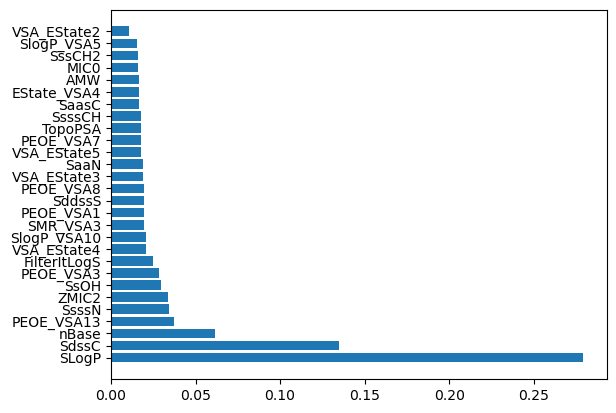

{'SLogP': 0.27933631373705703, 'SdssC': 0.13473687404408038, 'nBase': 0.061367621231008376, 'PEOE_VSA13': 0.037119199218878005, 'SsssN': 0.03434553521580621, 'ZMIC2': 0.03346102321143242, 'SsOH': 0.029752688541921004, 'PEOE_VSA3': 0.028606297923402565, 'FilterItLogS': 0.02493994293765824, 'VSA_EState4': 0.020746073059438742, 'SlogP_VSA10': 0.020613089281962788, 'SMR_VSA3': 0.01967662394224096, 'PEOE_VSA1': 0.019675745351872262, 'SddssS': 0.019492873129061315, 'PEOE_VSA8': 0.019293180624309188, 'VSA_EState3': 0.01918740294105806, 'SaaN': 0.018865558901258205, 'VSA_EState5': 0.017928398952093447, 'PEOE_VSA7': 0.01775771567090326, 'TopoPSA': 0.017748650153168226, 'SsssCH': 0.017510409865912187, 'SaasC': 0.01683143244270358, 'EState_VSA4': 0.016549704880228784, 'AMW': 0.016534224908488642, 'MIC0': 0.016048210470631836, 'SssCH2': 0.01578591420309289, 'SlogP_VSA5': 0.015276679928236815, 'VSA_EState2': 0.010812615232094817}


In [37]:
X_selected_descriptors, selected_features_descriptors, final_importance_descriptors = efficient_feature_selection(
    X = X_descriptors_train,
    y = y_train,
    min_features = 20,
    max_features = 30
)

plot_importance(selected_features_descriptors, final_importance_descriptors)

In [38]:
# spremanje odabranih značajki u X_train i X_test

X_descriptors_train = X_selected_descriptors.copy()
X_descriptors_test = X_descriptors_test[X_selected_descriptors.columns]

Uklonjeno je 143 autokorelacijskih deskriptora. Nakon RFECV selekcije, ostaje 28 deskriptora.

## 2.2. Molekularni otisci

Četiri vrste molekularnih otisaka (MACCS, Avalon, ECFP i ErG) generiraju se pomoću RDKit alata. Iako su inicijalno implementirani kao specijalizirani objekti, svi se otisci pretvaraju u binarne vektore radi jednostavnije obrade.

In [39]:
from rdkit.Chem import MACCSkeys
from rdkit.Chem.Pharm2D import Generate
from rdkit.Chem.Pharm2D import Gobbi_Pharm2D
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Avalon import pyAvalonTools

# MACCS
def maccs_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['maccs'] = data_train['smiles'].apply(maccs_to_numpy)
data_test['maccs'] = data_test['smiles'].apply(maccs_to_numpy)

# Avalon
data_train['avalon'] = data_train['smiles'].apply(
    lambda x: np.array(pyAvalonTools.GetAvalonFP(AllChem.MolFromSmiles(x), nBits=512)))
data_test['avalon'] = data_test['smiles'].apply(
    lambda x: np.array(pyAvalonTools.GetAvalonFP(AllChem.MolFromSmiles(x), nBits=512)))

# Morgan
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)
data_train['morgan'] = data_train['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))
data_test['morgan'] = data_test['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))

# ErG (2D Pharmacophore / Scaffold hopping)
factory = Gobbi_Pharm2D.factory
def erg_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = Generate.Gen2DFingerprint(mol, factory)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['erg'] = data_train['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))
data_test['erg'] = data_test['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))

In [40]:
print(len(data_train['maccs'].tolist()[0]), len(data_train['avalon'].tolist()[0]),
       len(data_train['morgan'].tolist()[0]), len(data_train['erg'].tolist()[0]))

167 512 512 39972


Nakon pretvaranja u binarne vektore, MACCS otisci su dimenzije 167, Avalon i ECFP otisci su dimenzija 512, a ErG dimenzije 39 972. Redukcija dimenzionalnosti na 128 bitova primjenjuje se na sve molekularne otiske.

Redukcija dimenzionalnosti molekularnih otisaka provodi se u dva koraka: uklanjanje gotovo konstantnih značajki te SVD rastav. Uklanjanje gotovo konstantnih značajki podrazumijeva uklanjanje vrijednosti koje su identične za većinu molekula te stoga nemaju diskriminacijsku moć. SVD rastav (dekompozicija matrice na singularne vrijednosti) je linearna metoda koja dekomponira matricu otisaka.

In [41]:
from sklearn.decomposition import TruncatedSVD

def reduce_fp(X_train, X_test):
    # X := (num_samples x 39972) numpy array

    # 1) Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.001)  # tune threshold
    X_var_train = selector.fit_transform(X_train)
    X_var_test = selector.transform(X_test)

    print(f"After variance thresholding: {X_var_test.shape}")

    # 2) Use TruncatedSVD to reduce dimensionality
    svd = TruncatedSVD(n_components=128, random_state=42)  # choose n_components based on explained variance or downstream task
    X_reduced_train = svd.fit_transform(X_var_train)
    X_reduced_test = svd.transform(X_var_test)

    print(f"After TruncatedSVD: {X_reduced_train.shape}\n")
    return X_reduced_train, X_reduced_test

X_maccs_train, X_maccs_test = reduce_fp(np.array(data_train['maccs'].tolist()), np.array(data_test['maccs'].tolist()))
X_avalon_train, X_avalon_test = reduce_fp(np.array(data_train['avalon'].tolist()), np.array(data_test['avalon'].tolist()))
X_morgan_train, X_morgan_test = reduce_fp(np.array(data_train['morgan'].tolist()), np.array(data_test['morgan'].tolist()))
X_erg_train, X_erg_test = reduce_fp(np.array(data_train['erg'].tolist()), np.array(data_test['erg'].tolist()))

After variance thresholding: (417, 146)
After TruncatedSVD: (3761, 128)

After variance thresholding: (417, 512)
After TruncatedSVD: (3761, 128)

After variance thresholding: (417, 512)
After TruncatedSVD: (3761, 128)

After variance thresholding: (417, 10949)
After TruncatedSVD: (3761, 128)



Svi se otisci spajaju u jednu kompozitnu reprezentaciju za potrebe treniranja i evaluacije prediktivnih modela.

In [42]:
X_fp_train = np.hstack([X_maccs_train, X_avalon_train, X_morgan_train, X_erg_train])
X_fp_test = np.hstack([X_maccs_test, X_avalon_test, X_morgan_test, X_erg_test])

## 2.3. Mol2Vec

Za generiranje prve vrste latentnih molekularnih reprezentacija koristi se unaprijed trenirani Mol2Vec model. Prije njegovog korištenja, SMILES zapisi molekula pretvaraju se u 2D strukture uz pomoć RDKit alata. Dobivene molekule potom služe kao ulazni podaci za Mol2Vec model, čime se SMILES zapisi relativno jednostavno pretvaraju u latentne reprezentacije.

In [43]:
from tqdm import tqdm

# zbog nekompatibilnosti verzija
def sentences2vec(sentences, model, unseen='UNK'):
    """
    Convert a list of sentences (molecular substructure tokens) into vector representations
    using a gensim Word2Vec model (Gensim 4.x compatible).

    Parameters:
    - sentences: list of lists of substructure tokens (e.g., [['[C@@H]', '[CH3]'], ...])
    - model: gensim Word2Vec model (must be trained or preloaded)
    - unseen: token to use for unseen words (default 'UNK')

    Returns:
    - list of numpy arrays (each array = vector for one molecule)
    """
    vectors = []
    for sentence in tqdm(sentences, desc="Embedding molecules"):
        vecs = []
        for word in sentence:
            if word in model.wv:
                vecs.append(model.wv[word])
            elif unseen in model.wv:
                vecs.append(model.wv[unseen])
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            # In case no known words in sentence, use zero vector
            vectors.append(np.zeros(model.vector_size))
    return vectors


In [44]:
import gensim
from mol2vec.features import mol2alt_sentence
# from tqdm import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Load model
model = gensim.models.Word2Vec.load("models/model_300dim.pkl")
sentences_train = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_train['smiles'].tolist()]
sentences_test = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_test['smiles'].tolist()]

# Convert to vectors
vectors_train = sentences2vec(sentences_train, model)
vectors_test = sentences2vec(sentences_test, model)
data_train['mol2vec'] = vectors_train
data_test['mol2vec'] = vectors_test

Embedding molecules: 100%|██████████| 417/417 [00:00<00:00, 9888.93it/s]


In [45]:
len(data_train['mol2vec'].tolist()[0])

300

Kako bi se olakšalo kasnije treniranje i usporedba prediktivnih modela, primijenjena je redukcija s 300 na 128 dimenzionalnosti korištenjem autoenkodera.

Autoenkoder se u ovom slučaju sastoji se od ulaznog sloja, jednog gustog sloja koji služi kao enkoder, te drugog gustog sloja koji služi kao dekoder Model je treniran tijekom 50 epoha na skupovima za treniranje, na podskupovima od 32 molekule. 

In [46]:
from tensorflow.keras import layers, models

def reduce_embedding_dim(X_train, X_test):
    """
    Reduce the dimensionality of embeddings using an autoencoder.
    """

    # Define autoencoder architecture
    input_dim = X_train.shape[1]
    encoding_dim = 128  # or whatever target dimension you want

    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
    decoded = layers.Dense(input_dim, activation='linear')(encoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)  # This gives compressed output

    # Compile and train
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, shuffle=True)

    X_reduced_train = encoder.predict(X_train)
    X_reduced_test = encoder.predict(X_test)
    
    return X_reduced_train, X_reduced_test

X_mol2vec_train, X_mol2vec_test = reduce_embedding_dim(np.array([emb for emb  in data_train['mol2vec']]), 
                                                       np.array([emb for emb in data_test['mol2vec']]))



Epoch 1/100

118/118 [==============================] - 1s 2ms/step - loss: 0.0021
Epoch 2/100
118/118 [==============================] - 0s 1ms/step - loss: 7.1097e-04
Epoch 3/100
118/118 [==============================] - 0s 1ms/step - loss: 5.0083e-04
Epoch 4/100
118/118 [==============================] - 0s 1ms/step - loss: 4.0863e-04
Epoch 5/100
118/118 [==============================] - 0s 1ms/step - loss: 3.5351e-04
Epoch 6/100
118/118 [==============================] - 0s 1ms/step - loss: 3.1310e-04
Epoch 7/100
118/118 [==============================] - 0s 1ms/step - loss: 2.8490e-04
Epoch 8/100
118/118 [==============================] - 0s 1ms/step - loss: 2.6321e-04
Epoch 9/100
118/118 [==============================] - 0s 1ms/step - loss: 2.4533e-04
Epoch 10/100
118/118 [==============================] - 0s 1ms/step - loss: 2.3025e-04
Epoch 11/100
118/118 [==============================] - 0s 1ms/step - loss: 2.1809e-04
Epoch 12/100
118/118 [==============================]

## 2.4. ChemBERTa

Generiranje druge vrste latentnih reprezentacija, korištenjem ChemBERTe, nešto je složeniji i vremenski zahtjevniji proces. I ovaj je model unaprijed treniran na velikom broju molekula, no ovdje se dodatno trenira na skupu za treniranje predikcije potentosti. Treniranje se provodi tijekom 20 epoha korištenjem trostruke unakrsne validacije, pri čemu se kao optimizator koristi Adam algoritam sa stopom učenja 10−5. Nakon dodatnog podešavanja, model se koristi za generiranje latentnih reprezentacija molekula u skupu za testiranje.

In [47]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch.nn as nn
from torch.utils.data import Dataset
import torch

model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(smiles):
    return tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')

class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets):
        self.inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors='pt')
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return (
            self.inputs['input_ids'][idx],
            self.inputs['attention_mask'][idx],
            self.targets[idx]
        )
    
class ChemBERTaRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.chemberta.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.chemberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(pooled_output), pooled_output  # return both prediction and embedding


def train_model(model, dataloader, optimizer, device):
    model.train()
    for input_ids, attn_mask, targets in dataloader:
        input_ids, attn_mask, targets = input_ids.to(device), attn_mask.to(device), targets.to(device)
        preds, _ = model(input_ids, attn_mask)
        loss = nn.MSELoss()(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


Dodatno ćemo trenirati model u 20 epoha te ćemo koristiti trostruku unakrsnu validaciju.

In [48]:
from sklearn.model_selection import KFold
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.optim import Adam
from torch.utils.data import Dataset


smiles_list = data_train['smiles'].tolist()
targets = data_train['lipo'].tolist()

inputs = tokenize(smiles_list)
X = inputs['input_ids']
attention = inputs['attention_mask']
y = torch.tensor(targets).float().unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_EPOCHS = 20
N_SPLITS = 3

for epoch in range(N_EPOCHS):
    print(f"\n=== Epoch {epoch+1} ===")
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=epoch)  # New shuffle per epoch

    fold_mse_list = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(smiles_list)):
        print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

        # Split data
        train_smiles = [smiles_list[i] for i in train_idx]
        val_smiles = [smiles_list[i] for i in val_idx]
        train_targets = y[train_idx]
        val_targets = y[val_idx]

        # Dataset and loaders
        train_dataset = SMILESDataset(train_smiles, train_targets)
        val_dataset = SMILESDataset(val_smiles, val_targets)
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        # New model per fold
        model = ChemBERTaRegressor(model_name).to(device)
        optimizer = Adam(model.parameters(), lr=2e-5)

        # Train model for 1 epoch only (we’re inside the global epoch loop)
        train_model(model, train_loader, optimizer, device)

        # Evaluate on validation fold
        model.eval()
        all_preds, all_targets = [], []

        with torch.no_grad():
            for input_ids, attn_mask, targets in val_loader:
                input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
                preds, _ = model(input_ids, attn_mask)
                all_preds.append(preds.cpu())
                all_targets.append(targets)

        preds_cat = torch.cat(all_preds).squeeze()
        targets_cat = torch.cat(all_targets).squeeze()
        mse = nn.MSELoss()(preds_cat, targets_cat)
        fold_mse_list.append(mse.item())
        print(f"Fold {fold+1} MSE: {mse.item():.4f}")

    epoch_avg_mse = sum(fold_mse_list) / N_SPLITS
    print(f"\n✅ Epoch {epoch+1} Average MSE across folds: {epoch_avg_mse:.4f}")



=== Epoch 1 ===

--- Fold 1/3 ---


C:\Users\afs\AppData\Local\Temp\ipykernel_20408\3240592466.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.targets = torch.tensor(targets).float().unsqueeze(1)
c:\Users\afs\anaconda3\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
c:\Users\afs\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([16, 1, 1])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same 

Fold 1 MSE: 0.0427

--- Fold 2/3 ---
Fold 2 MSE: 0.0399

--- Fold 3/3 ---


c:\Users\afs\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([12, 1, 1])) that is different to the input size (torch.Size([12, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Fold 3 MSE: 0.0455

✅ Epoch 1 Average MSE across folds: 0.0427

=== Epoch 2 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0426

--- Fold 2/3 ---
Fold 2 MSE: 0.0510

--- Fold 3/3 ---
Fold 3 MSE: 0.0426

✅ Epoch 2 Average MSE across folds: 0.0454

=== Epoch 3 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0566

--- Fold 2/3 ---
Fold 2 MSE: 0.0422

--- Fold 3/3 ---
Fold 3 MSE: 0.0420

✅ Epoch 3 Average MSE across folds: 0.0469

=== Epoch 4 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0433

--- Fold 2/3 ---
Fold 2 MSE: 0.0446

--- Fold 3/3 ---
Fold 3 MSE: 0.0508

✅ Epoch 4 Average MSE across folds: 0.0462

=== Epoch 5 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0417

--- Fold 2/3 ---
Fold 2 MSE: 0.0419

--- Fold 3/3 ---
Fold 3 MSE: 0.0399

✅ Epoch 5 Average MSE across folds: 0.0412

=== Epoch 6 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0459

--- Fold 2/3 ---
Fold 2 MSE: 0.0404

--- Fold 3/3 ---
Fold 3 MSE: 0.0410

✅ Epoch 6 Average MSE across folds: 0.0424

=== Epoch 7 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0400

--- Fold 2/3 ---
Fold 

In [49]:
from torch.utils.data import DataLoader, TensorDataset

train_embed_dataset = TensorDataset(X, attention)
train_embed_loader = DataLoader(train_embed_dataset, batch_size=32)

model.eval()
all_embeddings = []

with torch.no_grad():
    for input_ids, attn_mask in train_embed_loader:
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
        _, embeddings = model(input_ids, attn_mask)
        all_embeddings.append(embeddings.cpu())

embeddings_train = torch.cat(all_embeddings).numpy()

data_train['embedding'] = [emb for emb in embeddings_train]

In [50]:
del embeddings_train
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [51]:
from torch.utils.data import DataLoader, TensorDataset

inputs_test = tokenize(data_test['smiles'].tolist())
X_test = inputs_test['input_ids']
attention_test = inputs_test['attention_mask']
y_test = torch.tensor(data_test['lipo'].tolist()).float().unsqueeze(1)


test_embed_dataset = TensorDataset(X_test, attention_test)
test_embed_loader = DataLoader(test_embed_dataset, batch_size=32)

model.eval()
all_embeddings = []

with torch.no_grad():
    for input_ids, attn_mask in test_embed_loader:
        input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
        _, embeddings = model(input_ids, attn_mask)
        all_embeddings.append(embeddings.cpu())

embeddings_test = torch.cat(all_embeddings).numpy()

data_test['embedding'] = [emb for emb in embeddings_test]

In [41]:
torch.save(model, './models/chemberta_v3.pt')

In [52]:
len(data_train['embedding'].tolist()[0])

768

Dimenzionalnost latentne reprezentacije smanjuje se na isti način kao i kod Mol2Vec, korištenjem autoenkodera.

In [53]:
X_chemberta_train, X_chemberta_test = reduce_embedding_dim(np.array([emb for emb in data_train['embedding']]), 
                                                           np.array([emb for emb in data_test['embedding']]))

Epoch 1/100
118/118 [==============================] - 1s 2ms/step - loss: 0.1327
Epoch 2/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0454
Epoch 3/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0346
Epoch 4/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0289
Epoch 5/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0252
Epoch 6/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0223
Epoch 7/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0201
Epoch 8/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0185
Epoch 9/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0171
Epoch 10/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0162
Epoch 11/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0154
Epoch 12/100
118/118 [==============================] - 0s 2ms/step - loss: 0.0146
Epoch 13/100


Slijede funkcije za spremanje i učitavanje generiranih molekularnih reprezentacija, kako se dugotrajni postupci ne bi morali ponavljati iznova.

In [1]:
import pickle

# # TRAIN SET
# with open("./data/X_descriptors_train_lipo.pkl", "wb") as f:
#     pickle.dump(X_descriptors_train, f)

# with open("./data/X_fp_train_lipo.pkl", "wb") as f:
#     pickle.dump(X_fp_train, f)

# with open("./data/X_mol2vec_train_lipo.pkl", "wb") as f:
#     pickle.dump(X_mol2vec_train, f)

# with open("./data/X_chemberta_train_lipo.pkl", "wb") as f:
#     pickle.dump(X_chemberta_train, f)

# with open("./data/data_train_lipo.pkl", "wb") as f:
#     pickle.dump(data_train, f)

# # TEST SET
# with open("./data/X_descriptors_test_lipo.pkl", "wb") as f:
#     pickle.dump(X_descriptors_test, f)

# with open("./data/X_fp_test_lipo.pkl", "wb") as f:
#     pickle.dump(X_fp_test, f)

# with open("./data/X_mol2vec_test_lipo.pkl", "wb") as f:
#     pickle.dump(X_mol2vec_test, f)

# with open("./data/X_chemberta_test_lipo.pkl", "wb") as f:
#     pickle.dump(X_chemberta_test, f)

# with open("./data/data_test_lipo.pkl", "wb") as f:
#     pickle.dump(data_test, f)



with open("./data/X_descriptors_train_lipo.pkl", "rb") as f:
    X_descriptors_train = pickle.load(f)

with open("./data/X_fp_train_lipo.pkl", "rb") as f:
    X_fp_train = pickle.load(f)

with open("./data/X_mol2vec_train_lipo.pkl", "rb") as f:
    X_mol2vec_train = pickle.load(f)

with open("./data/X_chemberta_train_lipo.pkl", "rb") as f:
    X_chemberta_train = pickle.load(f)

with open("./data/data_train_lipo.pkl", "rb") as f:
    data_train = pickle.load(f)

with open("./data/X_descriptors_test_lipo.pkl", "rb") as f:
    X_descriptors_test = pickle.load(f)

with open("./data/X_fp_test_lipo.pkl", "rb") as f:
    X_fp_test = pickle.load(f)

with open("./data/X_mol2vec_test_lipo.pkl", "rb") as f:
    X_mol2vec_test = pickle.load(f)

with open("./data/X_chemberta_test_lipo.pkl", "rb") as f:
    X_chemberta_test = pickle.load(f)

with open("./data/data_test_lipo.pkl", "rb") as f:
    data_test = pickle.load(f)

# 3. Usporedba prediktivnih modela

Za predikciju molekularnih svojstava koriste se tri različita modela: slučajna šuma (RF), stroj potpornih vektora (SVM) te HGBR (Hist Gradient Boosting Regressor).

Svaki od ovih modela trenira se zasebno na četiri različite vrste molekularnih reprezentacija: molekularnim deskriptorima, spojenom skupu molekularnih otisaka, latentnoj reprezentaciji dobivenoj Mol2Vec-om te latentnoj reprezentaciji dobivenoj ChemBERTom. Zadnje dvije vrste reprezentacija tretiraju se odvojeno zbog njihove različite prirode i primijenjenih NLP tehnika, čime se omogućuje usporedba njihovih performansi. 

Također, modeli su trenirani na kombiniranim molekularnim reprezentacijama koje nastaju spajanjem različitih skupova značajki u jedinstveni vektor. Na temelju rezultata bit će moguće zaključiti poboljšavaju li se performanse prediktivnih modela kombinacijom različitih molekularnih reprezentacija.

Kako bi se dodatno testirale performanse pristupa koji kombinira različite molekularne reprezentacije, modeli trenirani na svakoj od četiri vrste molekularnih reprezentacija spajaju se u složeni ansambl (stacking ensemble). Kao meta-model koristi se Ridge regresija, oblik linearne regresije
s primijenjenom L2 regularizacijom. Ridge regresija preferira se kao meta-model jer je otporna na korelirane ulaze, manje sklona prenaučenosti, računalno je efikasna te se pokazala uspješnom u ansambl učenju.

Prije treniranja, sve su ulazne molekularne značajke standardiziraju se na istu skalu.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_descriptors_train = scaler.fit_transform(X_descriptors_train.values)
X_descriptors_test = scaler.transform(X_descriptors_test.values)

X_fp_train = scaler.fit_transform(X_fp_train)
X_fp_test = scaler.transform(X_fp_test)

X_mol2vec_train = scaler.fit_transform(X_mol2vec_train)
X_mol2vec_test = scaler.transform(X_mol2vec_test)

X_chemberta_train = scaler.fit_transform(X_chemberta_train)
X_chemberta_test = scaler.transform(X_chemberta_test)

Treniranje RF i modela provodi se trostrukom unakrsnom validacijom na skupu za treniranje. Optimizacija hiperparametara za RF i SVM vrši se
zasebno za svaki model metodom rešetke (Grid Search) 

Optimizacija hiperparametara HGBR modela provodi se metodom nasumične pretrage (Randomized Search).

Performanse prediktivnih modela evaluiraju se na temelju tri metrike: srednje kvadratne pogreške (MSE), srednje apsolutne pogreške (MAE) i koeficijenta determinacije R2.

In [55]:
import numpy as np

X_combined_train = np.hstack([
    X_descriptors_train,
    X_fp_train,
    X_mol2vec_train,
    X_chemberta_train
])

y_train = np.array(data_train['lipo'])

X_combined_test = np.hstack([
    X_descriptors_test,
    X_fp_test,
    X_mol2vec_test,
    X_chemberta_test
])

y_test = np.array(data_test['lipo'])

## 3.1. RF

In [56]:
# molekularni deskriptori
print('Molekularni deskriptori')
rf_descriptors, rf_descriptors_time = train_rf(X_descriptors_train, y_train)
evaluate_model(rf_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, rf_descriptors_time)

# molekularni otisci
print('Molekularni otisci')
rf_fp, rf_fp_time = train_rf(X_fp_train, y_train)
evaluate_model(rf_fp, X_fp_train, y_train, X_fp_test, y_test, rf_fp_time)

# mol2vec
print('Mol2Vec')
rf_mol2vec, rf_mol2vec_time = train_rf(X_mol2vec_train, y_train)
evaluate_model(rf_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, rf_mol2vec_time)

# chemberta
print('Chemberta')
rf_chemberta, rf_chemberta_time = train_rf(X_chemberta_train, y_train)
evaluate_model(rf_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, rf_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 9.38 seconds
📊 Train RMSE: 0.0429, MAE: 0.0327, R2: 0.9522
📊 Test  RMSE: 0.1200, MAE: 0.0905, R2: 0.6326

Molekularni otisci
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 33.49 seconds
📊 Train RMSE: 0.0623, MAE: 0.0480, R2: 0.8993
📊 Test  RMSE: 0.1477, MAE: 0.1145, R2: 0.4437

Mol2Vec
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 10.87 seconds
📊 Train RMSE: 0.0580, MAE: 0.0458, R2: 0.9126
📊 Test  RMSE: 0.1440, MAE: 0.1122, R2: 0.4709

Chemberta
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 8.51 seconds
📊 Train RMSE: 0.0597, MAE: 0.0468, R2: 0.9075
📊 Test  RMSE: 0.1542, MAE: 0.1245, R2: 0.3936



In [58]:
# kombinacija
print('Kombinirane molekularne reprezentacije')
rf_combined, rf_combined_time = train_rf(X_combined_train, y_train)
evaluate_model(rf_combined, X_combined_train, y_train, X_combined_test, y_test, rf_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 37.56 seconds
📊 Train RMSE: 0.0588, MAE: 0.0451, R2: 0.9101
📊 Test  RMSE: 0.1351, MAE: 0.1050, R2: 0.5344



In [59]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    rf_descriptors.predict(X_descriptors_train),
    rf_fp.predict(X_fp_train),
    rf_mol2vec.predict(X_mol2vec_train),
    rf_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    rf_descriptors.predict(X_descriptors_test),
    rf_fp.predict(X_fp_test),
    rf_mol2vec.predict(X_mol2vec_test),
    rf_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl')
print(f'Training RMSE: {root_mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test RMSE: {root_mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Ansambl
Training RMSE: 0.0284, MAE: 0.0223, R2: 0.9790
Test RMSE: 0.1255, MAE: 0.0965, R2: 0.5981


Iako ansambl modela treniranih na različitim molekularnim reprezentacijama daje uvjerljivo najbolje rezultate, situacija na skupu za testiranje to ne potvrđuje. Oba načina kombi nacije molekularnih deskriptora daju bolje rezultate od molekularnih otisaka i latentnih reprezentacija, no u ovom slučaju molekularni deskriptori ipak daju najbolje rezultate.


Mogući razlog je jednostavnost i diskretnost skupa molekularnih deskriptora, što idealno odgovara modelima poput slučajne šume koji do svojih zaključaka dolaze diskretnim putem.

## 3.1. SVM

In [60]:
# molekularni deskriptori
print('Molekularni deskriptori')
svm_descriptors, svm_descriptors_time = train_svm(X_descriptors_train, y_train)
evaluate_model(svm_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, svm_descriptors_time)

# molekularni otisci
print('Molekularni otisci')
svm_fp, svm_fp_time = train_svm(X_fp_train, y_train)
evaluate_model(svm_fp, X_fp_train, y_train, X_fp_test, y_test, svm_fp_time)

# mol2vec
print('Mol2Vec')
svm_mol2vec, svm_mol2vec_time = train_svm(X_mol2vec_train, y_train)
evaluate_model(svm_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, svm_mol2vec_time)

# chemberta
print('Chemberta')
svm_chemberta, svm_chemberta_time = train_svm(X_chemberta_train, y_train)
evaluate_model(svm_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, svm_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 3.39 seconds
📊 Train RMSE: 0.0676, MAE: 0.0397, R2: 0.8815
📊 Test  RMSE: 0.1176, MAE: 0.0856, R2: 0.6469

Molekularni otisci
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 25.17 seconds
📊 Train RMSE: 0.0157, MAE: 0.0106, R2: 0.9936
📊 Test  RMSE: 0.1062, MAE: 0.0762, R2: 0.7122

Mol2Vec
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 5.97 seconds
📊 Train RMSE: 0.0465, MAE: 0.0247, R2: 0.9438
📊 Test  RMSE: 0.1130, MAE: 0.0812, R2: 0.6741

Chemberta
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 6.00 seconds
📊 Train RMSE: 0.0854, MAE: 0.0757, R2: 0.8108
📊 Test  RMSE: 0.1406, MAE: 0.1112, R2: 0.4957



In [61]:
# kombinacija
print('Kombinirane molekularne reprezentacije')
svm_combined, svm_combined_time = train_svm(X_combined_train, y_train)
evaluate_model(svm_combined, X_combined_train, y_train, X_combined_test, y_test, svm_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 41.74 seconds
📊 Train RMSE: 0.0170, MAE: 0.0107, R2: 0.9925
📊 Test  RMSE: 0.0966, MAE: 0.0682, R2: 0.7619



In [62]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    svm_descriptors.predict(X_descriptors_train),
    svm_fp.predict(X_fp_train),
    svm_mol2vec.predict(X_mol2vec_train),
    svm_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    svm_descriptors.predict(X_descriptors_test),
    svm_fp.predict(X_fp_test),
    svm_mol2vec.predict(X_mol2vec_test),
    svm_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Ansambl
Training MSE: 0.0003, MAE: 0.0096, R2: 0.9934
Test MSE: 0.0109, MAE: 0.0746, R2: 0.7228


Na skupu za treniranje najbolje rezultate daju molekularni otisci i ansambl. Na skupu za testiranje ipak najbolje rezultate daje SVM model treniran na kombinaciji molekularnih reprezentacija.

## 3.3. HistGradientBoostingRegressor

In [63]:
# molekularni deskriptori
print('Molekularni deskriptori')
hist_descriptors, hist_descriptors_time = train_histgb(X_descriptors_train, y_train)
evaluate_model(hist_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, hist_descriptors_time)

# molekularni otisci
print('Molekularni otisci')
hist_fp, hist_fp_time = train_histgb(X_fp_train, y_train)
evaluate_model(hist_fp, X_fp_train, y_train, X_fp_test, y_test, hist_fp_time)

# mol2vec
print('Mol2Vec')
hist_mol2vec, hist_mol2vec_time = train_histgb(X_mol2vec_train, y_train)
evaluate_model(hist_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, hist_mol2vec_time)

# chemberta
print('Chemberta')
hist_chemberta, hist_chemberta_time = train_histgb(X_chemberta_train, y_train)
evaluate_model(hist_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, hist_chemberta_time)

Molekularni deskriptori
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 4.00 seconds
📊 Train RMSE: 0.0750, MAE: 0.0567, R2: 0.8542
📊 Test  RMSE: 0.1197, MAE: 0.0894, R2: 0.6342

Molekularni otisci
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 141.09 seconds
📊 Train RMSE: 0.0570, MAE: 0.0386, R2: 0.9156
📊 Test  RMSE: 0.1292, MAE: 0.0983, R2: 0.5740

Mol2Vec
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 22.22 seconds
📊 Train RMSE: 0.0521, MAE: 0.0320, R2: 0.9297
📊 Test  RMSE: 0.1301, MAE: 0.0970, R2: 0.5682

Chemberta
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 12.26 seconds
📊 Train RMSE: 0.0950, MAE: 0.0735, R2: 0.7657
📊 Test  RMSE: 0.1540, MAE: 0.1235, R2: 0.3951



In [64]:
# combined
print('Kombinirane molekularne reprezentacije')
hist_combined, hist_combined_time = train_histgb(X_combined_train, y_train)
evaluate_model(hist_combined, X_combined_train, y_train, X_combined_test, y_test, hist_combined_time)

Kombinirane molekularne reprezentacije
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 164.55 seconds
📊 Train RMSE: 0.0612, MAE: 0.0459, R2: 0.9028
📊 Test  RMSE: 0.1110, MAE: 0.0832, R2: 0.6857



In [65]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    hist_descriptors.predict(X_descriptors_train),
    hist_fp.predict(X_fp_train),
    hist_mol2vec.predict(X_mol2vec_train),
    hist_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    hist_descriptors.predict(X_descriptors_test),
    hist_fp.predict(X_fp_test),
    hist_mol2vec.predict(X_mol2vec_test),
    hist_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Ansambl')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Ansambl
Training MSE: 0.0023, MAE: 0.0296, R2: 0.9411
Test MSE: 0.0141, MAE: 0.0880, R2: 0.6415


Uvjerljivo najbolje rezultate na skupovima za
treniranje i testiranje daje kombinacija molekularnih reprezentacija.

# 4. Zaključak
